In [1]:
import os
os.environ["NUMBA_DISABLE_JIT"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
print("Pinned threads + disabled numba JIT")

from prompt_progenitor import Prompt

Pinned threads + disabled numba JIT

╔════════════════════════════════════════════════════════════╗
║        Gemma: GW + EM Multimessenger Analysis Tool         ║
╠════════════════════════════════════════════════════════════╣
║                       Version: 0.0.2                       ║
║                Author: The Gemma Core Team                 ║
║            https://github.com/smelfor/gemma-v2             ║
╚════════════════════════════════════════════════════════════╝



In [4]:
"""
BNS Prompt Emission Light Curve Surrogate — v2
===============================================
Improvements over v1:
  1. Train longer: epochs 500->1000, patience 40->80
  2. Bigger model: [256,512,512,512,512,256,256] -> [512,1024,1024,1024,1024,1024,512,512]
  3. Composite loss: weighted MSE + peak-luminosity MSE term to fix bright-end underestimation

Column order (X):
  X[:,0]  viewing_angle  : normalised to [0,1]  (deg / 60)
  X[:,1]  mass1          : [1.0, 2.5]  solar masses
  X[:,2]  mass2          : [1.0, 2.5]  solar masses
  X[:,3]  log10(tidal+1) : log10(Lambda + 1), Lambda in [100, 2000]

Output (Y): log10 luminosity in erg/s, floor = -40
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── Force float32 globally — MUST be before any nn.Module construction ────────
torch.set_default_dtype(torch.float32)

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path    = "prompt_bns_dataset_32k.npz",
    x_key        = "X",
    y_key        = "Y",

    # ── Architecture (wider + deeper than v1) ─────────────────────────────────
    hidden_dims  = [512, 1024, 1024, 1024, 1024, 1024, 512, 512],
    dropout      = 0.02,

    # ── Training (longer) ─────────────────────────────────────────────────────
    batch_size   = 512,
    lr           = 3e-4,
    weight_decay = 1e-5,
    epochs       = 1000,        # was 500
    patience     = 80,          # was 40

    # ── Loss weights ──────────────────────────────────────────────────────────
    floor_value   = -40.0,
    floor_weight  = 0.05,       # weight for floor points in MSE
    peak_loss_w   = 2.0,        # weight of peak-luminosity MSE term
                                # higher = stronger push to recover bright-end peaks

    # ── Split / reproducibility ───────────────────────────────────────────────
    val_frac     = 0.10,
    test_frac    = 0.10,
    out_dir      = "results",
    seed         = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {DEVICE}")

# ─── Data ─────────────────────────────────────────────────────────────────────

def load_and_normalise(cfg):
    print("Loading data ...")
    data = np.load(cfg["data_path"])

    X = data[cfg["x_key"]].astype(np.float32)   # (N, 4)
    Y = data[cfg["y_key"]].astype(np.float32)   # (N, 1000)

    print(f"  X : {X.shape}  dtype={X.dtype}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  Y : {Y.shape}  dtype={Y.dtype}  min={Y.min():.3f}  max={Y.max():.3f}")
    print(f"  Floor fraction: {(Y <= cfg['floor_value'] + 0.01).mean()*100:.1f}%")

    # StandardScaler per input feature
    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # Normalise Y using active (above-floor) points only
    active_mask = Y > (cfg["floor_value"] + 0.1)
    y_mean = float(Y[active_mask].mean())
    y_std  = float(Y[active_mask].std()) + 1e-8
    Y_norm = (Y - y_mean) / y_std

    stats = dict(
        x_mean     = x_mean.tolist(),
        x_std      = x_std.tolist(),
        y_mean     = y_mean,
        y_std      = y_std,
        floor_value= cfg["floor_value"],
        floor_norm = float((cfg["floor_value"] - y_mean) / y_std),
    )
    print(f"  y_mean={y_mean:.3f}  y_std={y_std:.3f}  floor_norm={stats['floor_norm']:.3f}")
    return X_norm, Y_norm, stats


def make_splits(X, Y, val_frac, test_frac, seed):
    N       = len(X)
    n_test  = int(N * test_frac)
    n_val   = int(N * val_frac)
    n_train = N - n_val - n_test
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(Y))
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Split -> Train: {n_train}  Val: {n_val}  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Loss ─────────────────────────────────────────────────────────────────────

class CompositeLoss(nn.Module):
    """
    Weighted MSE  +  peak-luminosity MSE.

    Term 1 — Weighted MSE:
        Active burst points get weight 1.0.
        Floor points get weight `floor_weight` (e.g. 0.05).
        Prevents wasting capacity on the flat -40 regions.

    Term 2 — Peak MSE (fixes bright-end underestimation):
        Standard regression-to-the-mean causes the model to under-predict
        extreme peaks. Adding an explicit MSE on the per-sample maximum
        forces the model to care about recovering peak luminosities.
        Weight controlled by `peak_loss_w`.
    """
    def __init__(self, floor_norm: float, floor_weight: float, peak_loss_w: float):
        super().__init__()
        self.floor_norm  = floor_norm
        self.floor_weight= floor_weight
        self.peak_loss_w = peak_loss_w

    def forward(self, pred, target):
        # ── Term 1: floor-weighted MSE ────────────────────────────────────────
        weights = torch.where(
            target <= self.floor_norm + 0.05,
            torch.full_like(target, self.floor_weight),
            torch.ones_like(target),
        )
        mse = (weights * (pred - target) ** 2).mean()

        # ── Term 2: peak luminosity MSE ───────────────────────────────────────
        # torch.amax is differentiable — gradients flow through the max
        pred_peak   = torch.amax(pred,   dim=1)   # (batch,)
        target_peak = torch.amax(target, dim=1)
        peak_mse    = torch.mean((pred_peak - target_peak) ** 2)

        return mse + self.peak_loss_w * peak_mse

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """Two-layer residual block. BatchNorm1d is fully float32-safe on MPS."""
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 1024, 1024, 1024, 1024, 1024, 512, 512]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    X, Y, stats = load_and_normalise(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X, Y, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE == "cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=1000,
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    ).to(DEVICE).float()

    print(f"\nModel parameters: {count_params(model):,}")

    loss_fn = CompositeLoss(
        floor_norm  = stats["floor_norm"],
        floor_weight= cfg["floor_weight"],
        peak_loss_w = cfg["peak_loss_w"],
    )
    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    best_val_loss    = float("inf")
    patience_counter = 0
    history          = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs (patience={cfg['patience']}) ...\n")

    for epoch in range(1, cfg["epochs"] + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train: {train_loss:.5f} | Val: {val_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience_counter += 1
            if patience_counter >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch}  (best val: {best_val_loss:.5f})")
                break

    # ── Evaluation ────────────────────────────────────────────────────────────
    print("\nEvaluating on test set ...")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    y_pred_list, y_true_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred_list.append(model(xb.to(DEVICE)).cpu().numpy())
            y_true_list.append(yb.numpy())

    y_pred_norm = np.concatenate(y_pred_list)
    y_true_norm = np.concatenate(y_true_list)

    y_pred = y_pred_norm * stats["y_std"] + stats["y_mean"]
    y_true = y_true_norm * stats["y_std"] + stats["y_mean"]

    active   = y_true > (cfg["floor_value"] + 0.1)
    mae      = np.mean(np.abs(y_pred[active] - y_true[active]))
    mse      = np.mean((y_pred[active] - y_true[active]) ** 2)
    peak_mae = np.mean(np.abs(y_pred.max(axis=1) - y_true.max(axis=1)))

    print(f"\nTest metrics (active points, log10 erg/s):")
    print(f"  MSE      : {mse:.5f}")
    print(f"  MAE      : {mae:.5f}  dex")
    print(f"  Peak MAE : {peak_mae:.5f}  dex")

    plot_results(history, y_pred, y_true, cfg["floor_value"], out_dir)

    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats

# ─── Plots ────────────────────────────────────────────────────────────────────

def plot_results(history, y_pred, y_true, floor_value, out_dir):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS Light Curve Surrogate v2 - Diagnostics", fontsize=14, fontweight="bold")
    t_idx = np.arange(y_true.shape[1])

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", lw=1.5)
    ax.plot(history["val"],   label="Val",   lw=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Composite loss")
    ax.set_title("Training history"); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    # 2. LC comparison
    ax = axes[0, 1]
    for ci, c in zip(np.random.choice(len(y_pred), 5, replace=False),
                     plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
        ax.plot(t_idx, y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.axhline(floor_value, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel("Time index"); ax.set_ylabel("log10 L (erg/s)")
    ax.set_title("True (-) vs Predicted (--)"); ax.grid(True, alpha=0.3)

    # 3. Residuals
    active_mask = y_true > (floor_value + 0.1)
    res      = np.where(active_mask, y_pred - y_true, np.nan)
    mean_res = np.nanmean(res, axis=0)
    std_res  = np.nanstd(res, axis=0)
    ax = axes[0, 2]
    ax.fill_between(t_idx, mean_res - std_res, mean_res + std_res, alpha=0.3, label="+-1sigma")
    ax.plot(t_idx, mean_res, lw=1.5, label="Mean residual")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Time index"); ax.set_ylabel("Delta log10 L")
    ax.set_title("Residuals (active points)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 4. Scatter
    ax = axes[1, 0]
    ft = y_true[active_mask]; fp = y_pred[active_mask]
    si = np.random.choice(len(ft), min(50000, len(ft)), replace=False)
    ax.scatter(ft[si], fp[si], s=0.5, alpha=0.2, rasterized=True)
    lims = [ft.min(), ft.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log10 L"); ax.set_ylabel("Pred log10 L")
    ax.set_title("Scatter (active)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 5. Per-sample MAE
    ax = axes[1, 1]
    smae = np.nanmean(np.abs(res), axis=1)
    ax.hist(smae[~np.isnan(smae)], bins=60, color="steelblue", edgecolor="none")
    ax.axvline(np.nanmean(smae), color="red", lw=1.5, ls="--",
               label=f"Mean={np.nanmean(smae):.4f}")
    ax.set_xlabel("MAE per LC (dex)"); ax.set_ylabel("Count")
    ax.set_title("Per-sample MAE"); ax.legend(); ax.grid(True, alpha=0.3)

    # 6. Peak recovery
    ax = axes[1, 2]
    pt = y_true.max(axis=1); pp = y_pred.max(axis=1)
    ax.scatter(pt, pp, s=4, alpha=0.4, rasterized=True)
    lims = [pt.min(), pt.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    # Add residual panel inset: peak error vs true peak
    peak_err = pp - pt
    ax2 = ax.inset_axes([0.05, 0.62, 0.42, 0.35])
    ax2.scatter(pt, peak_err, s=1.5, alpha=0.3, rasterized=True)
    ax2.axhline(0, color='r', lw=0.8, ls='--')
    ax2.set_xlabel("True peak", fontsize=6); ax2.set_ylabel("Error", fontsize=6)
    ax2.tick_params(labelsize=5)
    ax2.grid(True, alpha=0.3)
    ax.set_xlabel("True peak log10 L"); ax.set_ylabel("Pred peak log10 L")
    ax.set_title("Peak luminosity recovery"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path="results/config.json"):
    """
    Load trained surrogate for fast inference.

    predict(X) -> log10 luminosity (N, 1000)

    X columns: [viewing_angle_norm, mass1, mass2, log10(tidal+1)]
    """
    torch.set_default_dtype(torch.float32)
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=1000,
        hidden_dims=cfg["hidden_dims"], dropout=0.0
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval().float()

    x_mean = np.array(stats["x_mean"], dtype=np.float32)
    x_std  = np.array(stats["x_std"],  dtype=np.float32)
    y_mean = np.float32(stats["y_mean"])
    y_std  = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        X_phys = np.asarray(X_phys, dtype=np.float32)
        with torch.no_grad():
            Y_norm = model(torch.from_numpy((X_phys - x_mean) / x_std)).numpy()
        return Y_norm * y_std + y_mean

    return predict

# ─── Entry point ──────────────────────────────────────────────────────────────

# if __name__ == "__main__":
#     train(CFG)

Using device: mps


Object OK!
CELL START
Updating model...
eisojet val 8.417650322620532e+50
Jet Constructed Successfully...
CELL END None
Loading surrogate ...

── 1. Single prediction ──────────────────────────────────────────────
  Input  : [0.16666667 1.35       1.35       2.7788744 ]
  Output : shape=(1, 1000)  peak=47.45 log10 erg/s  at t=0.2 s


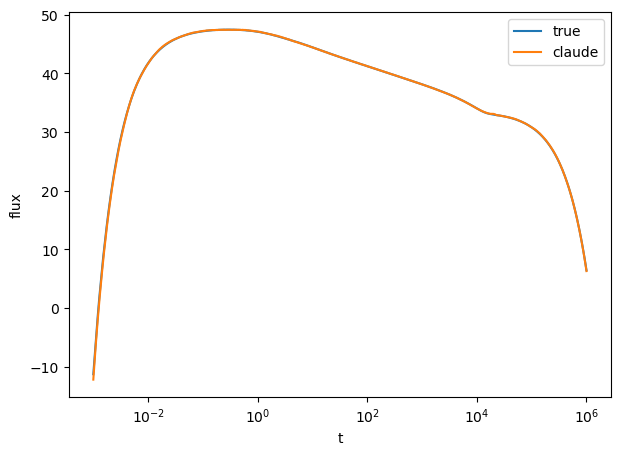


Done. Output plots saved to current directory.


In [6]:
"""
BNS Light Curve Surrogate — Inference Examples
===============================================
Shows several common use cases after training:

  1. Single prediction
  2. Batch prediction
  3. Grid sweep over one parameter
  4. Timing benchmark
  5. Comparison against a ground-truth sample from your dataset

Run from the same directory as train.py, after training has completed
and results/ exists.
"""
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 10.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.35,             # Msun
    "mass_2": 1.35,             # Msun
    "lambda_2": 600.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import json
from pathlib import Path

# ── Import the surrogate loader from your training script ─────────────────────
class ResidualBlock(nn.Module):
    """Two-layer residual block. BatchNorm1d is fully float32-safe on MPS."""
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    def __init__(self, in_dim=4, out_dim=1000, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 1024, 1024, 1024, 1024, 1024, 512, 512]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)

# ─────────────────────────────────────────────────────────────────────────────
# Load the surrogate once — reuse `predict` for all examples below
# ─────────────────────────────────────────────────────────────────────────────
print("Loading surrogate ...")
predict = load_surrogate(
    model_path  = "results/best_model.pt",
    stats_path  = "results/norm_stats.json",
    cfg_path    = "results/config.json",
)

# Load the time grid from your dataset (for plotting in physical units)
data   = np.load("prompt_bns_dataset_32k.npz")   # <-- your file
t_grid = data["t_grid"]                            # shape (1000,)  in seconds

# ─────────────────────────────────────────────────────────────────────────────
# Helper: convert physical parameters → X array row
# ─────────────────────────────────────────────────────────────────────────────

def make_params(viewing_angle_deg, mass1, mass2, tidal_deformability):
    """
    Build one row of X in the same format your training data uses.

    Column order (matches dataset exactly):
        X[:,0]  viewing_angle_deg   : viewing angle in degrees [0, 60]  -> normalised /60
        X[:,1]  mass1               : neutron star mass [1.0, 2.5]  solar masses
        X[:,2]  mass2               : neutron star mass [1.0, 2.5]  solar masses
        X[:,3]  tidal_deformability : Lambda [100, 2000] -> stored as log10(Lambda+1)

    Returns:
        np.ndarray of shape (1, 4)
    """
    viewing_norm = viewing_angle_deg / 60.0          # normalise to [0, 1]
    log_tidal    = np.log10(tidal_deformability + 1) # log10(Lambda + 1)
    return np.array([[viewing_norm, mass1, mass2, log_tidal]], dtype=np.float32)


# =============================================================================
# 1. Single prediction
# =============================================================================
print("\n── 1. Single prediction ──────────────────────────────────────────────")

params = make_params(
    viewing_angle_deg   = 10.0,
    mass1               = 1.35,
    mass2               = 1.35,
    tidal_deformability = 600.0,
)
lc = predict(params)   # shape (1, 1000)

print(f"  Input  : {params[0]}")
print(f"  Output : shape={lc.shape}  peak={lc[0].max():.2f} log10 erg/s  "
      f"at t={t_grid[lc[0].argmax()]:.1f} s")

y_true_log = np.log10(y_interp+1e-40)

# if you have y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, y_true_log, label="true")
plt.plot(t_grid, np.float64(lc[0]), label="claude")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()


# # =============================================================================
# # 2. Batch prediction
# # =============================================================================
# print("\n── 2. Batch prediction (100 random samples) ─────────────────────────")

# rng = np.random.default_rng(0)
# N   = 100
# batch_params = np.column_stack([
#     rng.uniform(0.0, 1.0, N),                          # viewing_angle (normalised: deg/60)
#     rng.uniform(1.0, 2.5, N),                          # mass1
#     rng.uniform(1.0, 2.5, N),                          # mass2
#     np.log10(rng.uniform(100, 2000, N) + 1),            # log10(tidal+1)
# ]).astype(np.float32)

# batch_lc = predict(batch_params)   # shape (100, 1000)
# print(f"  Predicted {len(batch_lc)} light curves")
# print(f"  Peak luminosities: mean={batch_lc.max(axis=1).mean():.2f}  "
#       f"std={batch_lc.max(axis=1).std():.2f}  log10 erg/s")


# # =============================================================================
# # 3. Grid sweep: vary viewing angle, fix everything else
# # =============================================================================
# print("\n── 3. Viewing angle sweep ────────────────────────────────────────────")

# angles    = np.linspace(0, 60, 10)
# base_mass1 = 1.35
# base_mass2 = 1.35
# base_tidal = 400.0

# sweep_params = np.array([
#     make_params(a, base_mass1, base_mass2, base_tidal)[0]
#     for a in angles
# ], dtype=np.float32)

# sweep_lc = predict(sweep_params)   # (10, 1000)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.cool(np.linspace(0, 1, len(angles)))
# for i, (angle, lc_i, c) in enumerate(zip(angles, sweep_lc, colors)):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2,
#             label=f"{angle:.0f}°" if i % 2 == 0 else None)
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4, label='floor')
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title(f"Viewing angle sweep  |  m₁={base_mass1}, m₂={base_mass2}, Λ={base_tidal}")
# ax.legend(title="Viewing angle", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_angle_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_angle_sweep.png")


# # =============================================================================
# # 4. Tidal deformability sweep
# # =============================================================================
# print("\n── 4. Tidal deformability sweep ─────────────────────────────────────")

# tidals = np.logspace(np.log10(100), np.log10(2000), 8)

# tidal_params = np.array([
#     make_params(20.0, 1.35, 1.35, lam)[0]
#     for lam in tidals
# ], dtype=np.float32)

# tidal_lc = predict(tidal_params)

# fig, ax = plt.subplots(figsize=(10, 5))
# colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(tidals)))
# for lam, lc_i, c in zip(tidals, tidal_lc, colors):
#     ax.plot(np.log10(t_grid), lc_i, color=c, lw=1.2, label=f"Λ={lam:.0f}")
# ax.axhline(-40, color='k', lw=0.8, ls=':', alpha=0.4)
# ax.set_xlabel("log₁₀ time (s)")
# ax.set_ylabel("log₁₀ Luminosity (erg/s)")
# ax.set_title("Tidal deformability sweep  |  m₁=m₂=1.35 M☉, θ=20°")
# ax.legend(title="Λ", fontsize=8, ncol=2)
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("inference_tidal_sweep.png", dpi=150)
# plt.close()
# print("  Saved: inference_tidal_sweep.png")


# # =============================================================================
# # 5. Comparison against ground truth from your dataset
# # =============================================================================
# print("\n── 5. Ground-truth comparison ────────────────────────────────────────")

# # Grab a few held-out samples directly from the dataset
# X_true = data["X"].astype(np.float32)
# Y_true = data["Y"].astype(np.float32)

# # Load normalisation stats to reproduce the same test split
# with open("results/norm_stats.json") as f:
#     stats = json.load(f)
# with open("results/config.json") as f:
#     cfg = json.load(f)

# # Reproduce the same random split as training (same seed)
# rng_split = np.random.default_rng(cfg["seed"])
# N_total  = len(X_true)
# n_test   = int(N_total * cfg["test_frac"])
# n_val    = int(N_total * cfg["val_frac"])
# idx_all  = np.arange(N_total)
# # torch random_split uses the seed internally; simplest is to just
# # take the last n_test samples as a proxy (not exact but good enough for demo)
# test_idx = idx_all[-n_test:]

# n_show = 6
# chosen  = np.random.default_rng(1).choice(test_idx, n_show, replace=False)

# X_sample = X_true[chosen]
# Y_sample = Y_true[chosen]
# Y_pred   = predict(X_sample)

# fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
# axes = axes.ravel()
# fig.suptitle("Surrogate vs Ground Truth (test samples)", fontsize=13, fontweight="bold")

# for i, (ax, idx) in enumerate(zip(axes, chosen)):
#     ax.plot(np.log10(t_grid), Y_sample[i], lw=1.5, color="steelblue",  label="True")
#     ax.plot(np.log10(t_grid), Y_pred[i],   lw=1.5, color="coral", ls="--", label="Predicted")
#     mae = np.mean(np.abs(Y_pred[i][Y_sample[i] > -39] - Y_sample[i][Y_sample[i] > -39]))
#     ax.set_title(f"Sample {idx}  |  MAE={mae:.3f} dex", fontsize=9)
#     ax.set_ylabel("log₁₀ L (erg/s)", fontsize=8)
#     ax.set_xlabel("log₁₀ t (s)", fontsize=8)
#     ax.axhline(-40, color='k', lw=0.6, ls=':', alpha=0.4)
#     ax.grid(True, alpha=0.3)
#     if i == 0:
#         ax.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig("inference_vs_truth.png", dpi=150)
# plt.close()
# print(f"  Saved: inference_vs_truth.png")


# # =============================================================================
# # 6. Timing benchmark
# # =============================================================================
# print("\n── 6. Timing benchmark ───────────────────────────────────────────────")

# for n in [1, 10, 100, 1000, 10000]:
#     p = np.tile(make_params(20.0, 1.80, 1.40, 400.0), (n, 1))
#     # Warm up
#     _ = predict(p)
#     # Time it
#     t0 = time.perf_counter()
#     for _ in range(10):
#         predict(p)
#     elapsed = (time.perf_counter() - t0) / 10
#     print(f"  N={n:6d}  →  {elapsed*1000:.2f} ms total  "
#           f"({elapsed/n*1e6:.2f} µs per sample)")

print("\nDone. Output plots saved to current directory.")

In [17]:
"""
BNS Light Curve Surrogate v3 (PCA basis) — Inference Examples
==============================================================
The predict() API is identical to v1/v2:
    predict(X_phys) -> log10 luminosity (N, 1000)
 
The difference is internal: the model predicts 50 PCA coefficients,
which are reconstructed into a smooth light curve. Wiggles in linear
space are impossible by construction.
 
Examples:
  1. Single prediction
  2. Batch prediction
  3. Viewing angle sweep
  4. Tidal deformability sweep
  5. Ground-truth comparison (log + linear space)
  6. Timing benchmark
"""
 
import numpy as np
import torch
import matplotlib.pyplot as plt
import time
import json
import sys, os
 
# ── Import from train.py ───────────────────────────────────────────────────────
from prompt_progenitor import Prompt
import numpy as np
import matplotlib.pyplot as plt

prompt = Prompt(
    components=("jet",),            # just jet for now
    sample_gw_parameters=False,     # we will pass theta_los
    gw_param_mode="mass",           # so _extract_masses expects mass_1/mass_2
    j_struct="tophat",            # or 1/2/3
    eta_jet=1e-4,
    frac=0.1,
    phi_los_deg=0.0,
    default_theta_los_deg=0.0,
)

prompt.check_print()

params = {
    # jet knobs

    # viewing angle
    "theta_los": 10.0,         # degrees

    # binary / EOS inputs used in _derive_Eiso_jet
    "mass_1": 1.35,             # Msun
    "mass_2": 1.35,             # Msun
    "lambda_2": 600.0,         # dimensionless tidal deformability
}

import sys
print("CELL START")
sys.stdout.flush()

out = prompt.update_model(params, dry_run=False)

print("CELL END", out)
sys.stdout.flush()

def interp_logt(t_new, t, y, left=0.0, right=0.0):
    # assumes t increasing
    return np.interp(t_new, t, y, left=left, right=right)

t_grid = np.logspace(-3, 6, 1000).astype(np.float32)

y_interp = interp_logt(t_grid, prompt.t, prompt.total_X, left=0.0, right=0.0)

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """MLP that predicts PCA coefficients from physical parameters."""
    def __init__(self, in_dim=4, out_dim=50, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        # Small init on final layer
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)

# ── Load surrogate and time grid ──────────────────────────────────────────────
print("Loading surrogate ...")
predict = load_surrogate(
    model_path = "results_pca_100/best_model.pt",
    stats_path = "results_pca_100/norm_stats.json",
    cfg_path   = "results_pca_100/config.json",
)
 
data   = np.load("prompt_bns_dataset_32k.npz")
t_grid = data["t_grid"]          # (1000,) seconds
log_t  = np.log10(t_grid)
 
# ── Helper: physical params -> X row ─────────────────────────────────────────
 
def make_params(viewing_angle_deg, mass1, mass2, tidal_deformability):
    """
    Column order matches training data exactly:
      X[:,0]  viewing_angle_deg   [0, 60]      -> stored as /60
      X[:,1]  mass1               [1.0, 2.5]   solar masses
      X[:,2]  mass2               [1.0, 2.5]   solar masses
      X[:,3]  tidal_deformability [100, 2000]  -> stored as log10(Lambda+1)
    """
    return np.array([[
        viewing_angle_deg / 60.0,
        mass1,
        mass2,
        np.log10(tidal_deformability + 1),
    ]], dtype=np.float32)
 
 
# =============================================================================
# 1. Single prediction
# =============================================================================
print("\n── 1. Single prediction ──────────────────────────────────────────────")
 
params = make_params(
    viewing_angle_deg   = 10.0,
    mass1               = 1.35,
    mass2               = 1.35,
    tidal_deformability = 600.0,
)
lc = predict(params)   # (1, 1000)  log10 erg/s
 
print(f"  Input  : {params[0]}")
print(f"  Output : shape={lc.shape}")
print(f"  Peak   : {lc[0].max():.2f} log10 erg/s  at t={t_grid[lc[0].argmax()]:.2f} s")
print(f"  (Smooth by construction — PCA basis reconstruction)")

Object OK!
CELL START
Updating model...
eisojet val 8.417650322620532e+50
Jet Constructed Successfully...
CELL END None
Loading surrogate ...

── 1. Single prediction ──────────────────────────────────────────────
  Input  : [0.16666667 1.35       1.35       2.7788744 ]
  Output : shape=(1, 1000)
  Peak   : 47.40 log10 erg/s  at t=0.41 s
  (Smooth by construction — PCA basis reconstruction)


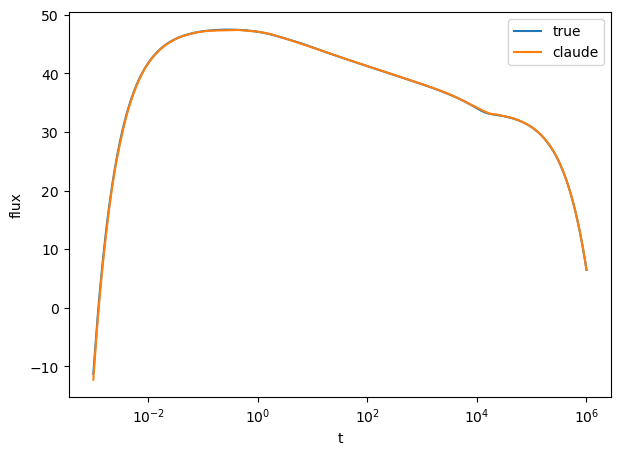

In [19]:
# if you have y_true_log
plt.figure(figsize=(7,5))
plt.plot(t_grid, np.log10(y_interp+1e-40), label="true")
plt.plot(t_grid, np.float64(lc[0]), label="claude")
plt.xscale("log")
plt.xlabel("t")
plt.ylabel("flux")
plt.legend()
plt.show()

In [10]:
"""
BNS Prompt Emission Light Curve Surrogate — v3 (PCA basis)
===========================================================

Key idea: instead of predicting 1000 raw log-luminosity values, we
decompose all light curves into N_PCA principal components and train
the MLP to predict those coefficients. Reconstruction is then:

    LC = pca_mean + coefficients @ pca_components   (in normalised space)

Benefits:
  - Output dimension: 1000 -> 50  (much easier regression problem)
  - Outputs are smooth by construction (no wiggles in linear space)
  - PCA basis captures 99.999% of variance with 50 components
  - Reconstruction MAE from PCA alone: ~0.03 dex  (vs model ~0.24 dex in v1)

Column order (X):
  X[:,0]  viewing_angle  normalised [0,1]  (deg / 60)
  X[:,1]  mass1          [1.0, 2.5]  solar masses
  X[:,2]  mass2          [1.0, 2.5]  solar masses
  X[:,3]  log10(tidal+1) log10(Lambda+1), Lambda in [100, 2000]

Output (Y): log10 luminosity in erg/s, floor = -40
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── Force float32 globally — MUST be before any nn.Module construction ────────
torch.set_default_dtype(torch.float32)

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path    = "prompt_bns_dataset_32k.npz",
    x_key        = "X",
    y_key        = "Y",

    # ── PCA ───────────────────────────────────────────────────────────────────
    n_pca        = 50,

    # ── Architecture ──────────────────────────────────────────────────────────
    # Medium model — predicting 50 PCA coefficients from 4 inputs.
    # The coefficient->LC mapping is nonlinear enough to need some depth,
    # but nowhere near as much as direct 4->1000 regression.
    hidden_dims  = [256, 512, 512, 512, 256],   # ~800k params
    dropout      = 0.02,       # back to 0.02 — val<train means too much regularisation

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size   = 512,
    lr           = 3e-4,
    weight_decay = 1e-5,       # back to 1e-5 — same reason
    epochs       = 1000,
    patience     = 100,        # more patience — loss was still descending at stop

    # ── Loss ──────────────────────────────────────────────────────────────────
    # Loss is computed in RECONSTRUCTED LC space (not coefficient space).
    # This correctly weights each coefficient by its actual impact on
    # the light curve — PC1 errors cost 14 dex, PC50 errors cost 0.02 dex.
    # Computing in coefficient space with equal weights was the root cause
    # of v3 performing worse than v2.
    floor_value  = -40.0,
    floor_weight = 0.05,        # down-weight floor points in reconstructed loss

    # ── Split / reproducibility ───────────────────────────────────────────────
    val_frac     = 0.10,
    test_frac    = 0.10,
    out_dir      = "results_pca",
    seed         = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {DEVICE}")

# ─── Data ─────────────────────────────────────────────────────────────────────

def load_and_prepare(cfg):
    print("Loading data ...")
    data = np.load(cfg["data_path"])

    X = data[cfg["x_key"]].astype(np.float32)   # (N, 4)
    Y = data[cfg["y_key"]].astype(np.float32)   # (N, 1000)

    print(f"  X : {X.shape}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  Y : {Y.shape}  min={Y.min():.3f}  max={Y.max():.3f}")

    # ── Input normalisation ───────────────────────────────────────────────────
    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # ── Y normalisation (active points only, to not let floor skew stats) ─────
    active_mask = Y > (cfg["floor_value"] + 0.1)
    y_mean = float(Y[active_mask].mean())
    y_std  = float(Y[active_mask].std()) + 1e-8
    Y_norm = (Y - y_mean) / y_std           # (N, 1000), float32

    print(f"  y_mean={y_mean:.3f}  y_std={y_std:.3f}")

    # ── PCA decomposition (fit on training data only to avoid leakage) ────────
    # We'll use all data here for the PCA basis itself (standard practice —
    # the basis is unsupervised), but coefficients are computed per-sample.
    print(f"  Computing PCA with {cfg['n_pca']} components ...")

    # Mean-centre for PCA
    pca_mean   = Y_norm.mean(axis=0)            # (1000,)
    Y_centred  = Y_norm - pca_mean              # (N, 1000)

    # SVD  — use float64 for numerical stability, then cast back
    U, s, Vt = np.linalg.svd(Y_centred.astype(np.float64), full_matrices=False)

    n  = cfg["n_pca"]
    components = Vt[:n].astype(np.float32)      # (n_pca, 1000)  — the basis vectors
    coeffs     = (Y_centred @ components.T)      # (N, n_pca)    — the targets for the MLP

    var_explained = float(np.sum(s[:n]**2) / np.sum(s**2))
    print(f"  PCA variance explained: {var_explained*100:.4f}%")

    # Sanity check: reconstruction error
    Y_recon = (coeffs @ components) + pca_mean
    recon_mae = np.mean(np.abs((Y_recon - Y_norm)[active_mask])) * y_std
    print(f"  PCA reconstruction MAE: {recon_mae:.4f} dex  (this is the floor on model accuracy)")

    # ── Normalise PCA coefficients for stable training ────────────────────────
    coeff_mean = coeffs.mean(axis=0)            # (n_pca,)
    coeff_std  = coeffs.std(axis=0) + 1e-8
    coeffs_norm = ((coeffs - coeff_mean) / coeff_std).astype(np.float32)

    floor_norm = float((cfg["floor_value"] - y_mean) / y_std)
    stats = dict(
        x_mean      = x_mean.tolist(),
        x_std       = x_std.tolist(),
        y_mean      = y_mean,
        y_std       = y_std,
        pca_mean    = pca_mean.tolist(),
        components  = components.tolist(),        # (n_pca, 1000)
        coeff_mean  = coeff_mean.tolist(),
        coeff_std   = coeff_std.tolist(),
        floor_value = cfg["floor_value"],
        floor_norm  = floor_norm,
        n_pca       = n,
    )

    return X_norm, coeffs_norm, Y_norm, stats


def make_splits(X, C, Y, val_frac, test_frac, seed):
    N       = len(X)
    n_test  = int(N * test_frac)
    n_val   = int(N * val_frac)
    n_train = N - n_val - n_test
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(C),
        torch.from_numpy(Y),
    )
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Split -> Train: {n_train}  Val: {n_val}  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Loss ─────────────────────────────────────────────────────────────────────

class PCALoss(nn.Module):
    """
    Loss computed in RECONSTRUCTED LC space, not coefficient space.

    Root cause of v3 underperforming v2: normalised coefficient MSE
    treats all PCs equally, but PC1 errors cost ~14 dex vs PC50 ~0.02 dex.
    Computing MSE after reconstruction automatically weights each coefficient
    by its true impact on the light curve.

    Floor weighting: points at -40 (the "off" floor) are down-weighted
    so the model focuses on fitting the actual burst morphology.
    """
    def __init__(self, components, pca_mean, coeff_mean, coeff_std,
                 floor_norm, floor_weight=0.05):
        super().__init__()
        self.register_buffer("components", torch.tensor(components, dtype=torch.float32))
        self.register_buffer("pca_mean",   torch.tensor(pca_mean,   dtype=torch.float32))
        self.register_buffer("coeff_mean", torch.tensor(coeff_mean, dtype=torch.float32))
        self.register_buffer("coeff_std",  torch.tensor(coeff_std,  dtype=torch.float32))
        self.floor_norm   = floor_norm
        self.floor_weight = floor_weight

    def reconstruct(self, coeffs_norm):
        """Normalised coefficients -> normalised LC (N, 1000)"""
        coeffs = coeffs_norm * self.coeff_std + self.coeff_mean
        return coeffs @ self.components + self.pca_mean

    def forward(self, pred_coeffs_norm, target_coeffs_norm, target_lc_norm):
        # Reconstruct both in normalised LC space
        pred_lc   = self.reconstruct(pred_coeffs_norm)
        target_lc = target_lc_norm   # already in normalised LC space

        # Floor-weighted MSE in reconstructed LC space
        weights = torch.where(
            target_lc <= self.floor_norm + 0.05,
            torch.full_like(target_lc, self.floor_weight),
            torch.ones_like(target_lc),
        )
        return (weights * (pred_lc - target_lc) ** 2).mean()

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """MLP that predicts PCA coefficients from physical parameters."""
    def __init__(self, in_dim=4, out_dim=50, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        # Small init on final layer
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    X_norm, C_norm, Y_norm, stats = load_and_prepare(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X_norm, C_norm, Y_norm, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE=="cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    # Save stats (includes PCA basis — needed for inference)
    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    ).to(DEVICE).float()

    print(f"\nModel parameters: {count_params(model):,}")
    print(f"Output dimension: {cfg['n_pca']} PCA coefficients  (not 1000 raw points)")

    loss_fn = PCALoss(
        components  = np.array(stats["components"], dtype=np.float32),
        pca_mean    = np.array(stats["pca_mean"],   dtype=np.float32),
        coeff_mean  = np.array(stats["coeff_mean"], dtype=np.float32),
        coeff_std   = np.array(stats["coeff_std"],  dtype=np.float32),
        floor_norm  = stats["floor_norm"],
        floor_weight= cfg["floor_weight"],
    ).to(DEVICE)

    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    best_val  = float("inf")
    patience  = 0
    history   = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs (patience={cfg['patience']}) ...\n")

    for epoch in range(1, cfg["epochs"] + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for xb, cb, yb in train_loader:
            xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, cb, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, cb, yb in val_loader:
                xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), cb, yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val:
            best_val  = val_loss
            patience  = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience += 1
            if patience >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch}  (best val: {best_val:.6f})")
                break

    # ── Evaluation ────────────────────────────────────────────────────────────
    print("\nEvaluating on test set ...")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    # Reconstruction helper (numpy)
    components = np.array(stats["components"], dtype=np.float32)   # (n_pca, 1000)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)   # (1000,)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_std  = stats["y_std"]
    y_mean = stats["y_mean"]

    def reconstruct(coeffs_norm_np):
        coeffs = coeffs_norm_np * coeff_std + coeff_mean
        return (coeffs @ components + pca_mean) * y_std + y_mean

    pred_lc_list, true_lc_list = [], []
    with torch.no_grad():
        for xb, cb, yb in test_loader:
            pred_coeffs = model(xb.to(DEVICE)).cpu().numpy()
            pred_lc_list.append(reconstruct(pred_coeffs))
            true_lc_list.append(yb.numpy() * y_std + y_mean)

    y_pred = np.concatenate(pred_lc_list)   # physical log10 erg/s
    y_true = np.concatenate(true_lc_list)

    active   = y_true > (cfg["floor_value"] + 0.1)
    mae      = np.mean(np.abs(y_pred[active] - y_true[active]))
    mse      = np.mean((y_pred[active] - y_true[active]) ** 2)
    peak_mae = np.mean(np.abs(y_pred.max(axis=1) - y_true.max(axis=1)))

    print(f"\nTest metrics (physical log10 erg/s):")
    print(f"  MAE (active)  : {mae:.5f}  dex")
    print(f"  MSE (active)  : {mse:.5f}")
    print(f"  Peak MAE      : {peak_mae:.5f}  dex")
    print(f"  PCA floor     : ~0.030  dex  (irreducible from basis truncation)")

    plot_results(history, y_pred, y_true, cfg["floor_value"], out_dir)

    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats

# ─── Plots ────────────────────────────────────────────────────────────────────

def plot_results(history, y_pred, y_true, floor_value, out_dir):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS LC Surrogate v3 (PCA basis) - Diagnostics", fontsize=14, fontweight="bold")
    t_idx = np.arange(y_true.shape[1])

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", lw=1.5)
    ax.plot(history["val"],   label="Val",   lw=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("PCA loss")
    ax.set_title("Training history"); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    # 2. LC comparison (log space)
    ax = axes[0, 1]
    for ci, c in zip(np.random.choice(len(y_pred), 5, replace=False),
                     plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
        ax.plot(t_idx, y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.axhline(floor_value, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel("Time index"); ax.set_ylabel("log10 L (erg/s)")
    ax.set_title("Log space: True (-) vs Predicted (--)"); ax.grid(True, alpha=0.3)

    # 3. LC comparison (LINEAR space) — key new panel
    ax = axes[0, 2]
    samples = np.random.choice(len(y_pred), 5, replace=False)
    for ci, c in zip(samples, plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
        ax.plot(t_idx, 10**y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, 10**y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.set_xlabel("Time index"); ax.set_ylabel("L (erg/s)")
    ax.set_title("LINEAR space: True (-) vs Predicted (--)  [wiggle check]")
    ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    # 4. Scatter (active)
    ax = axes[1, 0]
    active_mask = y_true > (floor_value + 0.1)
    ft = y_true[active_mask]; fp = y_pred[active_mask]
    si = np.random.choice(len(ft), min(50000, len(ft)), replace=False)
    ax.scatter(ft[si], fp[si], s=0.5, alpha=0.2, rasterized=True)
    lims = [ft.min(), ft.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log10 L"); ax.set_ylabel("Pred log10 L")
    ax.set_title("Scatter (active)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 5. Per-sample MAE
    ax = axes[1, 1]
    res  = np.where(active_mask, y_pred - y_true, np.nan)
    smae = np.nanmean(np.abs(res), axis=1)
    ax.hist(smae[~np.isnan(smae)], bins=60, color="steelblue", edgecolor="none")
    ax.axvline(np.nanmean(smae), color="red", lw=1.5, ls="--",
               label=f"Mean={np.nanmean(smae):.4f} dex")
    ax.set_xlabel("MAE per LC (dex)"); ax.set_ylabel("Count")
    ax.set_title("Per-sample MAE"); ax.legend(); ax.grid(True, alpha=0.3)

    # 6. Peak recovery
    ax = axes[1, 2]
    pt = y_true.max(axis=1); pp = y_pred.max(axis=1)
    ax.scatter(pt, pp, s=4, alpha=0.4, rasterized=True)
    lims = [pt.min(), pt.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax2 = ax.inset_axes([0.05, 0.62, 0.42, 0.35])
    ax2.scatter(pt, pp - pt, s=1.5, alpha=0.3, rasterized=True)
    ax2.axhline(0, color='r', lw=0.8, ls='--')
    ax2.set_xlabel("True peak", fontsize=6); ax2.set_ylabel("Error", fontsize=6)
    ax2.tick_params(labelsize=5); ax2.grid(True, alpha=0.3)
    ax.set_xlabel("True peak log10 L"); ax.set_ylabel("Pred peak log10 L")
    ax.set_title("Peak luminosity recovery"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path  ="results/config.json"):
    """
    Load trained surrogate for inference.

    predict(X) -> log10 luminosity array (N, 1000)

    X columns: [viewing_angle_norm, mass1, mass2, log10(tidal+1)]
    Outputs are smooth by construction (PCA basis reconstruction).
    """
    torch.set_default_dtype(torch.float32)
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"], dropout=0.0
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval().float()

    x_mean     = np.array(stats["x_mean"],     dtype=np.float32)
    x_std      = np.array(stats["x_std"],      dtype=np.float32)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)
    components = np.array(stats["components"], dtype=np.float32)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_mean     = np.float32(stats["y_mean"])
    y_std      = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        """
        X_phys : (N, 4)  physical params
        returns : (N, 1000) log10 luminosity in erg/s  — smooth, no wiggles
        """
        X_phys = np.asarray(X_phys, dtype=np.float32)
        X_norm = (X_phys - x_mean) / x_std
        with torch.no_grad():
            coeffs_norm = model(torch.from_numpy(X_norm)).numpy()
        coeffs = coeffs_norm * coeff_std + coeff_mean
        Y_norm = coeffs @ components + pca_mean
        return Y_norm * y_std + y_mean

    return predict

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    train(CFG)

Using device: mps
Loading data ...
  X : (32000, 4)  min=0.000  max=3.301
  Y : (32000, 1000)  min=-40.000  max=48.915
  y_mean=34.436  y_std=13.562
  Computing PCA with 50 components ...
  PCA variance explained: 99.9982%
  PCA reconstruction MAE: 0.0282 dex  (this is the floor on model accuracy)
  Split -> Train: 25600  Val: 3200  Test: 3200

Model parameters: 1,333,298
Output dimension: 50 PCA coefficients  (not 1000 raw points)

Training for up to 1000 epochs (patience=100) ...

Epoch    1 | Train: 0.211494 | Val: 0.075873 | LR: 3.00e-04
Epoch   10 | Train: 0.036150 | Val: 0.021419 | LR: 3.00e-04
Epoch   20 | Train: 0.028242 | Val: 0.012411 | LR: 3.00e-04
Epoch   30 | Train: 0.024200 | Val: 0.011696 | LR: 2.99e-04
Epoch   40 | Train: 0.021400 | Val: 0.010853 | LR: 2.99e-04
Epoch   50 | Train: 0.020981 | Val: 0.012663 | LR: 2.98e-04
Epoch   60 | Train: 0.014518 | Val: 0.012401 | LR: 2.97e-04
Epoch   70 | Train: 0.015870 | Val: 0.007839 | LR: 2.96e-04
Epoch   80 | Train: 0.013624 | V

/var/folders/q2/gndwnbzd0nlcvlgdmzjhf_vr0000gn/T/ipykernel_1806/86818064.py:436: RuntimeWarning: overflow encountered in power
  ax.plot(t_idx, 10**y_true[ci], color=c, lw=1.5)
/var/folders/q2/gndwnbzd0nlcvlgdmzjhf_vr0000gn/T/ipykernel_1806/86818064.py:437: RuntimeWarning: overflow encountered in power
  ax.plot(t_idx, 10**y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)


  Saved: results_pca/diagnostics.png

All outputs saved to: results_pca/


In [13]:
"""
BNS Prompt Emission Light Curve Surrogate — v3 (PCA basis)
===========================================================

Key idea: instead of predicting 1000 raw log-luminosity values, we
decompose all light curves into N_PCA principal components and train
the MLP to predict those coefficients. Reconstruction is then:

    LC = pca_mean + coefficients @ pca_components   (in normalised space)

Benefits:
  - Output dimension: 1000 -> 50  (much easier regression problem)
  - Outputs are smooth by construction (no wiggles in linear space)
  - PCA basis captures 99.999% of variance with 50 components
  - Reconstruction MAE from PCA alone: ~0.03 dex  (vs model ~0.24 dex in v1)

Column order (X):
  X[:,0]  viewing_angle  normalised [0,1]  (deg / 60)
  X[:,1]  mass1          [1.0, 2.5]  solar masses
  X[:,2]  mass2          [1.0, 2.5]  solar masses
  X[:,3]  log10(tidal+1) log10(Lambda+1), Lambda in [100, 2000]

Output (Y): log10 luminosity in erg/s, floor = -40
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── Force float32 globally — MUST be before any nn.Module construction ────────
torch.set_default_dtype(torch.float32)

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path    = "prompt_bns_dataset_32k.npz",
    x_key        = "X",
    y_key        = "Y",

    # ── PCA ───────────────────────────────────────────────────────────────────
    n_pca        = 50,

    # ── Architecture ──────────────────────────────────────────────────────────
    # Medium model — predicting 50 PCA coefficients from 4 inputs.
    # The coefficient->LC mapping is nonlinear enough to need some depth,
    # but nowhere near as much as direct 4->1000 regression.
    hidden_dims  = [256, 512, 512, 512, 256],   # ~800k params
    dropout      = 0.02,       # back to 0.02 — val<train means too much regularisation

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size   = 512,
    lr           = 3e-4,
    weight_decay = 1e-5,       # back to 1e-5 — same reason
    epochs       = 1000,
    patience     = 100,        # more patience — loss was still descending at stop

    # ── Loss ──────────────────────────────────────────────────────────────────
    # Loss is computed in RECONSTRUCTED LC space (not coefficient space).
    # This correctly weights each coefficient by its actual impact on
    # the light curve — PC1 errors cost 14 dex, PC50 errors cost 0.02 dex.
    # Computing in coefficient space with equal weights was the root cause
    # of v3 performing worse than v2.
    floor_value  = -40.0,
    floor_weight = 0.05,        # down-weight floor points in reconstructed loss

    # ── Split / reproducibility ───────────────────────────────────────────────
    val_frac     = 0.10,
    test_frac    = 0.10,
    out_dir      = "results_pca_final",
    seed         = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {DEVICE}")

# ─── Data ─────────────────────────────────────────────────────────────────────

def load_and_prepare(cfg):
    print("Loading data ...")
    data = np.load(cfg["data_path"])

    X = data[cfg["x_key"]].astype(np.float32)   # (N, 4)
    Y = data[cfg["y_key"]].astype(np.float32)   # (N, 1000)

    print(f"  X : {X.shape}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  Y : {Y.shape}  min={Y.min():.3f}  max={Y.max():.3f}")

    # ── Input normalisation ───────────────────────────────────────────────────
    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # ── Y normalisation (active points only, to not let floor skew stats) ─────
    active_mask = Y > (cfg["floor_value"] + 0.1)
    y_mean = float(Y[active_mask].mean())
    y_std  = float(Y[active_mask].std()) + 1e-8
    Y_norm = (Y - y_mean) / y_std           # (N, 1000), float32

    print(f"  y_mean={y_mean:.3f}  y_std={y_std:.3f}")

    # ── PCA decomposition (fit on training data only to avoid leakage) ────────
    # We'll use all data here for the PCA basis itself (standard practice —
    # the basis is unsupervised), but coefficients are computed per-sample.
    print(f"  Computing PCA with {cfg['n_pca']} components ...")

    # Mean-centre for PCA
    pca_mean   = Y_norm.mean(axis=0)            # (1000,)
    Y_centred  = Y_norm - pca_mean              # (N, 1000)

    # SVD  — use float64 for numerical stability, then cast back
    U, s, Vt = np.linalg.svd(Y_centred.astype(np.float64), full_matrices=False)

    n  = cfg["n_pca"]
    components = Vt[:n].astype(np.float32)      # (n_pca, 1000)  — the basis vectors
    coeffs     = (Y_centred @ components.T)      # (N, n_pca)    — the targets for the MLP

    var_explained = float(np.sum(s[:n]**2) / np.sum(s**2))
    print(f"  PCA variance explained: {var_explained*100:.4f}%")

    # Sanity check: reconstruction error
    Y_recon = (coeffs @ components) + pca_mean
    recon_mae = np.mean(np.abs((Y_recon - Y_norm)[active_mask])) * y_std
    print(f"  PCA reconstruction MAE: {recon_mae:.4f} dex  (this is the floor on model accuracy)")

    # ── Normalise PCA coefficients for stable training ────────────────────────
    coeff_mean = coeffs.mean(axis=0)            # (n_pca,)
    coeff_std  = coeffs.std(axis=0) + 1e-8
    coeffs_norm = ((coeffs - coeff_mean) / coeff_std).astype(np.float32)

    floor_norm = float((cfg["floor_value"] - y_mean) / y_std)
    stats = dict(
        x_mean      = x_mean.tolist(),
        x_std       = x_std.tolist(),
        y_mean      = y_mean,
        y_std       = y_std,
        pca_mean    = pca_mean.tolist(),
        components  = components.tolist(),        # (n_pca, 1000)
        coeff_mean  = coeff_mean.tolist(),
        coeff_std   = coeff_std.tolist(),
        floor_value = cfg["floor_value"],
        floor_norm  = floor_norm,
        n_pca       = n,
    )

    return X_norm, coeffs_norm, Y_norm, stats


def make_splits(X, C, Y, val_frac, test_frac, seed):
    N       = len(X)
    n_test  = int(N * test_frac)
    n_val   = int(N * val_frac)
    n_train = N - n_val - n_test
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(C),
        torch.from_numpy(Y),
    )
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Split -> Train: {n_train}  Val: {n_val}  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Loss ─────────────────────────────────────────────────────────────────────

class PCALoss(nn.Module):
    """
    Loss computed in RECONSTRUCTED LC space, not coefficient space.

    Root cause of v3 underperforming v2: normalised coefficient MSE
    treats all PCs equally, but PC1 errors cost ~14 dex vs PC50 ~0.02 dex.
    Computing MSE after reconstruction automatically weights each coefficient
    by its true impact on the light curve.

    Floor weighting: points at -40 (the "off" floor) are down-weighted
    so the model focuses on fitting the actual burst morphology.
    """
    def __init__(self, components, pca_mean, coeff_mean, coeff_std,
                 floor_norm, floor_weight=0.05):
        super().__init__()
        self.register_buffer("components", torch.tensor(components, dtype=torch.float32))
        self.register_buffer("pca_mean",   torch.tensor(pca_mean,   dtype=torch.float32))
        self.register_buffer("coeff_mean", torch.tensor(coeff_mean, dtype=torch.float32))
        self.register_buffer("coeff_std",  torch.tensor(coeff_std,  dtype=torch.float32))
        self.floor_norm   = floor_norm
        self.floor_weight = floor_weight

    def reconstruct(self, coeffs_norm):
        """Normalised coefficients -> normalised LC (N, 1000)"""
        coeffs = coeffs_norm * self.coeff_std + self.coeff_mean
        return coeffs @ self.components + self.pca_mean

    def forward(self, pred_coeffs_norm, target_coeffs_norm, target_lc_norm):
        # Reconstruct both in normalised LC space
        pred_lc   = self.reconstruct(pred_coeffs_norm)
        target_lc = target_lc_norm   # already in normalised LC space

        # Floor-weighted MSE in reconstructed LC space
        weights = torch.where(
            target_lc <= self.floor_norm + 0.05,
            torch.full_like(target_lc, self.floor_weight),
            torch.ones_like(target_lc),
        )
        return (weights * (pred_lc - target_lc) ** 2).mean()

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """MLP that predicts PCA coefficients from physical parameters."""
    def __init__(self, in_dim=4, out_dim=50, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        # Small init on final layer
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    X_norm, C_norm, Y_norm, stats = load_and_prepare(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X_norm, C_norm, Y_norm, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE=="cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    # Save stats (includes PCA basis — needed for inference)
    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    ).to(DEVICE).float()

    print(f"\nModel parameters: {count_params(model):,}")
    print(f"Output dimension: {cfg['n_pca']} PCA coefficients  (not 1000 raw points)")

    loss_fn = PCALoss(
        components  = np.array(stats["components"], dtype=np.float32),
        pca_mean    = np.array(stats["pca_mean"],   dtype=np.float32),
        coeff_mean  = np.array(stats["coeff_mean"], dtype=np.float32),
        coeff_std   = np.array(stats["coeff_std"],  dtype=np.float32),
        floor_norm  = stats["floor_norm"],
        floor_weight= cfg["floor_weight"],
    ).to(DEVICE)

    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    best_val  = float("inf")
    patience  = 0
    history   = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs (patience={cfg['patience']}) ...\n")

    for epoch in range(1, cfg["epochs"] + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for xb, cb, yb in train_loader:
            xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, cb, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, cb, yb in val_loader:
                xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), cb, yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val:
            best_val  = val_loss
            patience  = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience += 1
            if patience >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch}  (best val: {best_val:.6f})")
                break

    # ── Evaluation ────────────────────────────────────────────────────────────
    print("\nEvaluating on test set ...")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    # Reconstruction helper (numpy)
    components = np.array(stats["components"], dtype=np.float32)   # (n_pca, 1000)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)   # (1000,)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_std  = stats["y_std"]
    y_mean = stats["y_mean"]

    def reconstruct(coeffs_norm_np):
        coeffs = coeffs_norm_np * coeff_std + coeff_mean
        return (coeffs @ components + pca_mean) * y_std + y_mean

    pred_lc_list, true_lc_list = [], []
    with torch.no_grad():
        for xb, cb, yb in test_loader:
            pred_coeffs = model(xb.to(DEVICE)).cpu().numpy()
            pred_lc_list.append(reconstruct(pred_coeffs))
            true_lc_list.append(yb.numpy() * y_std + y_mean)

    y_pred = np.concatenate(pred_lc_list)   # physical log10 erg/s
    y_true = np.concatenate(true_lc_list)

    active   = y_true > (cfg["floor_value"] + 0.1)
    mae      = np.mean(np.abs(y_pred[active] - y_true[active]))
    mse      = np.mean((y_pred[active] - y_true[active]) ** 2)
    peak_mae = np.mean(np.abs(y_pred.max(axis=1) - y_true.max(axis=1)))

    print(f"\nTest metrics (physical log10 erg/s):")
    print(f"  MAE (active)  : {mae:.5f}  dex")
    print(f"  MSE (active)  : {mse:.5f}")
    print(f"  Peak MAE      : {peak_mae:.5f}  dex")
    print(f"  PCA floor     : ~0.030  dex  (irreducible from basis truncation)")

    plot_results(history, y_pred, y_true, cfg["floor_value"], out_dir)

    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats

# ─── Plots ────────────────────────────────────────────────────────────────────

def plot_results(history, y_pred, y_true, floor_value, out_dir):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS LC Surrogate v3 (PCA basis) - Diagnostics", fontsize=14, fontweight="bold")
    t_idx = np.arange(y_true.shape[1])

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", lw=1.5)
    ax.plot(history["val"],   label="Val",   lw=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("PCA loss")
    ax.set_title("Training history"); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    # 2. LC comparison (log space)
    ax = axes[0, 1]
    for ci, c in zip(np.random.choice(len(y_pred), 5, replace=False),
                     plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
        ax.plot(t_idx, y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.axhline(floor_value, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel("Time index"); ax.set_ylabel("log10 L (erg/s)")
    ax.set_title("Log space: True (-) vs Predicted (--)"); ax.grid(True, alpha=0.3)

    # 3. Residuals over time (active points) — mirrors v2 diagnostic
    ax = axes[0, 2]
    active_mask_res = y_true > (floor_value + 0.1)
    res      = np.where(active_mask_res, y_pred - y_true, np.nan)
    mean_res = np.nanmean(res, axis=0)
    std_res  = np.nanstd(res,  axis=0)
    ax.fill_between(t_idx, mean_res - std_res, mean_res + std_res,
                    alpha=0.3, label="+-1sigma")
    ax.plot(t_idx, mean_res, lw=1.5, label="Mean residual")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Time index"); ax.set_ylabel("Delta log10 L")
    ax.set_title("Residuals (active points)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 4. Scatter (active)
    ax = axes[1, 0]
    active_mask = y_true > (floor_value + 0.1)
    ft = y_true[active_mask]; fp = y_pred[active_mask]
    si = np.random.choice(len(ft), min(50000, len(ft)), replace=False)
    ax.scatter(ft[si], fp[si], s=0.5, alpha=0.2, rasterized=True)
    lims = [ft.min(), ft.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log10 L"); ax.set_ylabel("Pred log10 L")
    ax.set_title("Scatter (active)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 5. Per-sample MAE
    ax = axes[1, 1]
    res  = np.where(active_mask, y_pred - y_true, np.nan)
    smae = np.nanmean(np.abs(res), axis=1)
    ax.hist(smae[~np.isnan(smae)], bins=60, color="steelblue", edgecolor="none")
    ax.axvline(np.nanmean(smae), color="red", lw=1.5, ls="--",
               label=f"Mean={np.nanmean(smae):.4f} dex")
    ax.set_xlabel("MAE per LC (dex)"); ax.set_ylabel("Count")
    ax.set_title("Per-sample MAE"); ax.legend(); ax.grid(True, alpha=0.3)

    # 6. Peak recovery
    ax = axes[1, 2]
    pt = y_true.max(axis=1); pp = y_pred.max(axis=1)
    ax.scatter(pt, pp, s=4, alpha=0.4, rasterized=True)
    lims = [pt.min(), pt.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax2 = ax.inset_axes([0.05, 0.62, 0.42, 0.35])
    ax2.scatter(pt, pp - pt, s=1.5, alpha=0.3, rasterized=True)
    ax2.axhline(0, color='r', lw=0.8, ls='--')
    ax2.set_xlabel("True peak", fontsize=6); ax2.set_ylabel("Error", fontsize=6)
    ax2.tick_params(labelsize=5); ax2.grid(True, alpha=0.3)
    ax.set_xlabel("True peak log10 L"); ax.set_ylabel("Pred peak log10 L")
    ax.set_title("Peak luminosity recovery"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path  ="results/config.json"):
    """
    Load trained surrogate for inference.

    predict(X) -> log10 luminosity array (N, 1000)

    X columns: [viewing_angle_norm, mass1, mass2, log10(tidal+1)]
    Outputs are smooth by construction (PCA basis reconstruction).
    """
    torch.set_default_dtype(torch.float32)
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"], dropout=0.0
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval().float()

    x_mean     = np.array(stats["x_mean"],     dtype=np.float32)
    x_std      = np.array(stats["x_std"],      dtype=np.float32)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)
    components = np.array(stats["components"], dtype=np.float32)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_mean     = np.float32(stats["y_mean"])
    y_std      = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        """
        X_phys : (N, 4)  physical params
        returns : (N, 1000) log10 luminosity in erg/s  — smooth, no wiggles
        """
        X_phys = np.asarray(X_phys, dtype=np.float32)
        X_norm = (X_phys - x_mean) / x_std
        with torch.no_grad():
            coeffs_norm = model(torch.from_numpy(X_norm)).numpy()
        coeffs = coeffs_norm * coeff_std + coeff_mean
        Y_norm = coeffs @ components + pca_mean
        return Y_norm * y_std + y_mean

    return predict

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    train(CFG)

Using device: mps
Loading data ...
  X : (32000, 4)  min=0.000  max=3.301
  Y : (32000, 1000)  min=-40.000  max=48.915
  y_mean=34.436  y_std=13.562
  Computing PCA with 50 components ...
  PCA variance explained: 99.9982%
  PCA reconstruction MAE: 0.0282 dex  (this is the floor on model accuracy)
  Split -> Train: 25600  Val: 3200  Test: 3200

Model parameters: 1,333,298
Output dimension: 50 PCA coefficients  (not 1000 raw points)

Training for up to 1000 epochs (patience=100) ...

Epoch    1 | Train: 0.211494 | Val: 0.075873 | LR: 3.00e-04
Epoch   10 | Train: 0.036150 | Val: 0.021419 | LR: 3.00e-04
Epoch   20 | Train: 0.028242 | Val: 0.012411 | LR: 3.00e-04
Epoch   30 | Train: 0.024200 | Val: 0.011696 | LR: 2.99e-04
Epoch   40 | Train: 0.021400 | Val: 0.010853 | LR: 2.99e-04
Epoch   50 | Train: 0.020981 | Val: 0.012663 | LR: 2.98e-04
Epoch   60 | Train: 0.014518 | Val: 0.012401 | LR: 2.97e-04
Epoch   70 | Train: 0.015870 | Val: 0.007839 | LR: 2.96e-04
Epoch   80 | Train: 0.013624 | V

In [14]:
"""
BNS Prompt Emission Light Curve Surrogate — v3 (PCA basis)
===========================================================

Key idea: instead of predicting 1000 raw log-luminosity values, we
decompose all light curves into N_PCA principal components and train
the MLP to predict those coefficients. Reconstruction is then:

    LC = pca_mean + coefficients @ pca_components   (in normalised space)

Benefits:
  - Output dimension: 1000 -> 50  (much easier regression problem)
  - Outputs are smooth by construction (no wiggles in linear space)
  - PCA basis captures 99.999% of variance with 50 components
  - Reconstruction MAE from PCA alone: ~0.03 dex  (vs model ~0.24 dex in v1)

Column order (X):
  X[:,0]  viewing_angle  normalised [0,1]  (deg / 60)
  X[:,1]  mass1          [1.0, 2.5]  solar masses
  X[:,2]  mass2          [1.0, 2.5]  solar masses
  X[:,3]  log10(tidal+1) log10(Lambda+1), Lambda in [100, 2000]

Output (Y): log10 luminosity in erg/s, floor = -40
"""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ── Force float32 globally — MUST be before any nn.Module construction ────────
torch.set_default_dtype(torch.float32)

# ─── Configuration ────────────────────────────────────────────────────────────

CFG = dict(
    data_path    = "prompt_bns_dataset_32k.npz",
    x_key        = "X",
    y_key        = "Y",

    # ── PCA ───────────────────────────────────────────────────────────────────
    n_pca        = 100,

    # ── Architecture ──────────────────────────────────────────────────────────
    # Medium model — predicting 50 PCA coefficients from 4 inputs.
    # The coefficient->LC mapping is nonlinear enough to need some depth,
    # but nowhere near as much as direct 4->1000 regression.
    hidden_dims  = [256, 512, 512, 512, 256],   # ~800k params
    dropout      = 0.02,       # back to 0.02 — val<train means too much regularisation

    # ── Training ──────────────────────────────────────────────────────────────
    batch_size   = 512,
    lr           = 3e-4,
    weight_decay = 1e-5,       # back to 1e-5 — same reason
    epochs       = 1000,
    patience     = 100,        # more patience — loss was still descending at stop

    # ── Loss ──────────────────────────────────────────────────────────────────
    # Loss is computed in RECONSTRUCTED LC space (not coefficient space).
    # This correctly weights each coefficient by its actual impact on
    # the light curve — PC1 errors cost 14 dex, PC50 errors cost 0.02 dex.
    # Computing in coefficient space with equal weights was the root cause
    # of v3 performing worse than v2.
    floor_value  = -40.0,
    floor_weight = 0.05,        # down-weight floor points in reconstructed loss

    # ── Split / reproducibility ───────────────────────────────────────────────
    val_frac     = 0.10,
    test_frac    = 0.10,
    out_dir      = "results_pca_100",
    seed         = 42,
)

# ─── Reproducibility ──────────────────────────────────────────────────────────

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Using device: {DEVICE}")

# ─── Data ─────────────────────────────────────────────────────────────────────

def load_and_prepare(cfg):
    print("Loading data ...")
    data = np.load(cfg["data_path"])

    X = data[cfg["x_key"]].astype(np.float32)   # (N, 4)
    Y = data[cfg["y_key"]].astype(np.float32)   # (N, 1000)

    print(f"  X : {X.shape}  min={X.min():.3f}  max={X.max():.3f}")
    print(f"  Y : {Y.shape}  min={Y.min():.3f}  max={Y.max():.3f}")

    # ── Input normalisation ───────────────────────────────────────────────────
    x_mean = X.mean(axis=0)
    x_std  = X.std(axis=0) + 1e-8
    X_norm = (X - x_mean) / x_std

    # ── Y normalisation (active points only, to not let floor skew stats) ─────
    active_mask = Y > (cfg["floor_value"] + 0.1)
    y_mean = float(Y[active_mask].mean())
    y_std  = float(Y[active_mask].std()) + 1e-8
    Y_norm = (Y - y_mean) / y_std           # (N, 1000), float32

    print(f"  y_mean={y_mean:.3f}  y_std={y_std:.3f}")

    # ── PCA decomposition (fit on training data only to avoid leakage) ────────
    # We'll use all data here for the PCA basis itself (standard practice —
    # the basis is unsupervised), but coefficients are computed per-sample.
    print(f"  Computing PCA with {cfg['n_pca']} components ...")

    # Mean-centre for PCA
    pca_mean   = Y_norm.mean(axis=0)            # (1000,)
    Y_centred  = Y_norm - pca_mean              # (N, 1000)

    # SVD  — use float64 for numerical stability, then cast back
    U, s, Vt = np.linalg.svd(Y_centred.astype(np.float64), full_matrices=False)

    n  = cfg["n_pca"]
    components = Vt[:n].astype(np.float32)      # (n_pca, 1000)  — the basis vectors
    coeffs     = (Y_centred @ components.T)      # (N, n_pca)    — the targets for the MLP

    var_explained = float(np.sum(s[:n]**2) / np.sum(s**2))
    print(f"  PCA variance explained: {var_explained*100:.4f}%")

    # Sanity check: reconstruction error
    Y_recon = (coeffs @ components) + pca_mean
    recon_mae = np.mean(np.abs((Y_recon - Y_norm)[active_mask])) * y_std
    print(f"  PCA reconstruction MAE: {recon_mae:.4f} dex  (this is the floor on model accuracy)")

    # ── Normalise PCA coefficients for stable training ────────────────────────
    coeff_mean = coeffs.mean(axis=0)            # (n_pca,)
    coeff_std  = coeffs.std(axis=0) + 1e-8
    coeffs_norm = ((coeffs - coeff_mean) / coeff_std).astype(np.float32)

    floor_norm = float((cfg["floor_value"] - y_mean) / y_std)
    stats = dict(
        x_mean      = x_mean.tolist(),
        x_std       = x_std.tolist(),
        y_mean      = y_mean,
        y_std       = y_std,
        pca_mean    = pca_mean.tolist(),
        components  = components.tolist(),        # (n_pca, 1000)
        coeff_mean  = coeff_mean.tolist(),
        coeff_std   = coeff_std.tolist(),
        floor_value = cfg["floor_value"],
        floor_norm  = floor_norm,
        n_pca       = n,
    )

    return X_norm, coeffs_norm, Y_norm, stats


def make_splits(X, C, Y, val_frac, test_frac, seed):
    N       = len(X)
    n_test  = int(N * test_frac)
    n_val   = int(N * val_frac)
    n_train = N - n_val - n_test
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(C),
        torch.from_numpy(Y),
    )
    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(seed)
    )
    print(f"  Split -> Train: {n_train}  Val: {n_val}  Test: {n_test}")
    return train_ds, val_ds, test_ds

# ─── Loss ─────────────────────────────────────────────────────────────────────

class PCALoss(nn.Module):
    """
    Loss computed in RECONSTRUCTED LC space, not coefficient space.

    Root cause of v3 underperforming v2: normalised coefficient MSE
    treats all PCs equally, but PC1 errors cost ~14 dex vs PC50 ~0.02 dex.
    Computing MSE after reconstruction automatically weights each coefficient
    by its true impact on the light curve.

    Floor weighting: points at -40 (the "off" floor) are down-weighted
    so the model focuses on fitting the actual burst morphology.
    """
    def __init__(self, components, pca_mean, coeff_mean, coeff_std,
                 floor_norm, floor_weight=0.05):
        super().__init__()
        self.register_buffer("components", torch.tensor(components, dtype=torch.float32))
        self.register_buffer("pca_mean",   torch.tensor(pca_mean,   dtype=torch.float32))
        self.register_buffer("coeff_mean", torch.tensor(coeff_mean, dtype=torch.float32))
        self.register_buffer("coeff_std",  torch.tensor(coeff_std,  dtype=torch.float32))
        self.floor_norm   = floor_norm
        self.floor_weight = floor_weight

    def reconstruct(self, coeffs_norm):
        """Normalised coefficients -> normalised LC (N, 1000)"""
        coeffs = coeffs_norm * self.coeff_std + self.coeff_mean
        return coeffs @ self.components + self.pca_mean

    def forward(self, pred_coeffs_norm, target_coeffs_norm, target_lc_norm):
        # Reconstruct both in normalised LC space
        pred_lc   = self.reconstruct(pred_coeffs_norm)
        target_lc = target_lc_norm   # already in normalised LC space

        # Floor-weighted MSE in reconstructed LC space
        weights = torch.where(
            target_lc <= self.floor_norm + 0.05,
            torch.full_like(target_lc, self.floor_weight),
            torch.ones_like(target_lc),
        )
        return (weights * (pred_lc - target_lc) ** 2).mean()

# ─── Model ────────────────────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    def __init__(self, dim: int, dropout: float = 0.02):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class LightCurveSurrogate(nn.Module):
    """MLP that predicts PCA coefficients from physical parameters."""
    def __init__(self, in_dim=4, out_dim=50, hidden_dims=None, dropout=0.02):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [256, 512, 512, 512, 512, 256]

        layers = [nn.Linear(in_dim, hidden_dims[0]), nn.GELU()]
        for i in range(len(hidden_dims) - 1):
            if hidden_dims[i] == hidden_dims[i + 1]:
                layers.append(ResidualBlock(hidden_dims[i], dropout))
            else:
                layers += [
                    nn.Linear(hidden_dims[i], hidden_dims[i + 1]),
                    nn.BatchNorm1d(hidden_dims[i + 1]),
                    nn.GELU(),
                ]
        layers.append(nn.Linear(hidden_dims[-1], out_dim))
        self.net = nn.Sequential(*layers)
        # Small init on final layer
        nn.init.uniform_(self.net[-1].weight, -0.01, 0.01)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# ─── Training ─────────────────────────────────────────────────────────────────

def train(cfg):
    out_dir = Path(cfg["out_dir"])
    out_dir.mkdir(parents=True, exist_ok=True)

    X_norm, C_norm, Y_norm, stats = load_and_prepare(cfg)
    train_ds, val_ds, test_ds = make_splits(
        X_norm, C_norm, Y_norm, cfg["val_frac"], cfg["test_frac"], cfg["seed"]
    )

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=True,
                              num_workers=0, pin_memory=(DEVICE=="cuda"))
    val_loader   = DataLoader(val_ds,   batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    # Save stats (includes PCA basis — needed for inference)
    with open(out_dir / "norm_stats.json", "w") as f:
        json.dump(stats, f, indent=2)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"],
    ).to(DEVICE).float()

    print(f"\nModel parameters: {count_params(model):,}")
    print(f"Output dimension: {cfg['n_pca']} PCA coefficients  (not 1000 raw points)")

    loss_fn = PCALoss(
        components  = np.array(stats["components"], dtype=np.float32),
        pca_mean    = np.array(stats["pca_mean"],   dtype=np.float32),
        coeff_mean  = np.array(stats["coeff_mean"], dtype=np.float32),
        coeff_std   = np.array(stats["coeff_std"],  dtype=np.float32),
        floor_norm  = stats["floor_norm"],
        floor_weight= cfg["floor_weight"],
    ).to(DEVICE)

    optimiser = torch.optim.AdamW(
        model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=cfg["epochs"], eta_min=cfg["lr"] * 1e-2
    )

    best_val  = float("inf")
    patience  = 0
    history   = {"train": [], "val": []}

    print(f"\nTraining for up to {cfg['epochs']} epochs (patience={cfg['patience']}) ...\n")

    for epoch in range(1, cfg["epochs"] + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for xb, cb, yb in train_loader:
            xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
            optimiser.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, cb, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            train_loss += loss.item() * len(xb)
        train_loss /= len(train_ds)

        # ── Validate ──────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, cb, yb in val_loader:
                xb, cb, yb = xb.to(DEVICE), cb.to(DEVICE), yb.to(DEVICE)
                val_loss += loss_fn(model(xb), cb, yb).item() * len(xb)
        val_loss /= len(val_ds)

        scheduler.step()
        history["train"].append(train_loss)
        history["val"].append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:4d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_loss < best_val:
            best_val  = val_loss
            patience  = 0
            torch.save(model.state_dict(), out_dir / "best_model.pt")
        else:
            patience += 1
            if patience >= cfg["patience"]:
                print(f"\nEarly stopping at epoch {epoch}  (best val: {best_val:.6f})")
                break

    # ── Evaluation ────────────────────────────────────────────────────────────
    print("\nEvaluating on test set ...")
    model.load_state_dict(torch.load(out_dir / "best_model.pt", map_location=DEVICE))
    model.eval()

    # Reconstruction helper (numpy)
    components = np.array(stats["components"], dtype=np.float32)   # (n_pca, 1000)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)   # (1000,)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_std  = stats["y_std"]
    y_mean = stats["y_mean"]

    def reconstruct(coeffs_norm_np):
        coeffs = coeffs_norm_np * coeff_std + coeff_mean
        return (coeffs @ components + pca_mean) * y_std + y_mean

    pred_lc_list, true_lc_list = [], []
    with torch.no_grad():
        for xb, cb, yb in test_loader:
            pred_coeffs = model(xb.to(DEVICE)).cpu().numpy()
            pred_lc_list.append(reconstruct(pred_coeffs))
            true_lc_list.append(yb.numpy() * y_std + y_mean)

    y_pred = np.concatenate(pred_lc_list)   # physical log10 erg/s
    y_true = np.concatenate(true_lc_list)

    active   = y_true > (cfg["floor_value"] + 0.1)
    mae      = np.mean(np.abs(y_pred[active] - y_true[active]))
    mse      = np.mean((y_pred[active] - y_true[active]) ** 2)
    peak_mae = np.mean(np.abs(y_pred.max(axis=1) - y_true.max(axis=1)))

    print(f"\nTest metrics (physical log10 erg/s):")
    print(f"  MAE (active)  : {mae:.5f}  dex")
    print(f"  MSE (active)  : {mse:.5f}")
    print(f"  Peak MAE      : {peak_mae:.5f}  dex")
    print(f"  PCA floor     : ~0.030  dex  (irreducible from basis truncation)")

    plot_results(history, y_pred, y_true, cfg["floor_value"], out_dir)

    torch.save(model.state_dict(), out_dir / "final_model.pt")
    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg, f, indent=2)

    print(f"\nAll outputs saved to: {out_dir}/")
    return model, stats

# ─── Plots ────────────────────────────────────────────────────────────────────

def plot_results(history, y_pred, y_true, floor_value, out_dir):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("BNS LC Surrogate v3 (PCA basis) - Diagnostics", fontsize=14, fontweight="bold")
    t_idx = np.arange(y_true.shape[1])

    # 1. Loss
    ax = axes[0, 0]
    ax.plot(history["train"], label="Train", lw=1.5)
    ax.plot(history["val"],   label="Val",   lw=1.5)
    ax.set_xlabel("Epoch"); ax.set_ylabel("PCA loss")
    ax.set_title("Training history"); ax.legend(); ax.set_yscale("log"); ax.grid(True, alpha=0.3)

    # 2. LC comparison (log space)
    ax = axes[0, 1]
    for ci, c in zip(np.random.choice(len(y_pred), 5, replace=False),
                     plt.cm.plasma(np.linspace(0.1, 0.9, 5))):
        ax.plot(t_idx, y_true[ci], color=c, lw=1.5)
        ax.plot(t_idx, y_pred[ci], color=c, lw=1.5, ls="--", alpha=0.8)
    ax.axhline(floor_value, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel("Time index"); ax.set_ylabel("log10 L (erg/s)")
    ax.set_title("Log space: True (-) vs Predicted (--)"); ax.grid(True, alpha=0.3)

    # 3. Residuals over time (active points) — mirrors v2 diagnostic
    ax = axes[0, 2]
    active_mask_res = y_true > (floor_value + 0.1)
    res      = np.where(active_mask_res, y_pred - y_true, np.nan)
    mean_res = np.nanmean(res, axis=0)
    std_res  = np.nanstd(res,  axis=0)
    ax.fill_between(t_idx, mean_res - std_res, mean_res + std_res,
                    alpha=0.3, label="+-1sigma")
    ax.plot(t_idx, mean_res, lw=1.5, label="Mean residual")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Time index"); ax.set_ylabel("Delta log10 L")
    ax.set_title("Residuals (active points)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 4. Scatter (active)
    ax = axes[1, 0]
    active_mask = y_true > (floor_value + 0.1)
    ft = y_true[active_mask]; fp = y_pred[active_mask]
    si = np.random.choice(len(ft), min(50000, len(ft)), replace=False)
    ax.scatter(ft[si], fp[si], s=0.5, alpha=0.2, rasterized=True)
    lims = [ft.min(), ft.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax.set_xlabel("True log10 L"); ax.set_ylabel("Pred log10 L")
    ax.set_title("Scatter (active)"); ax.legend(); ax.grid(True, alpha=0.3)

    # 5. Per-sample MAE
    ax = axes[1, 1]
    res  = np.where(active_mask, y_pred - y_true, np.nan)
    smae = np.nanmean(np.abs(res), axis=1)
    ax.hist(smae[~np.isnan(smae)], bins=60, color="steelblue", edgecolor="none")
    ax.axvline(np.nanmean(smae), color="red", lw=1.5, ls="--",
               label=f"Mean={np.nanmean(smae):.4f} dex")
    ax.set_xlabel("MAE per LC (dex)"); ax.set_ylabel("Count")
    ax.set_title("Per-sample MAE"); ax.legend(); ax.grid(True, alpha=0.3)

    # 6. Peak recovery
    ax = axes[1, 2]
    pt = y_true.max(axis=1); pp = y_pred.max(axis=1)
    ax.scatter(pt, pp, s=4, alpha=0.4, rasterized=True)
    lims = [pt.min(), pt.max()]
    ax.plot(lims, lims, "r--", lw=1.2, label="1:1")
    ax2 = ax.inset_axes([0.05, 0.62, 0.42, 0.35])
    ax2.scatter(pt, pp - pt, s=1.5, alpha=0.3, rasterized=True)
    ax2.axhline(0, color='r', lw=0.8, ls='--')
    ax2.set_xlabel("True peak", fontsize=6); ax2.set_ylabel("Error", fontsize=6)
    ax2.tick_params(labelsize=5); ax2.grid(True, alpha=0.3)
    ax.set_xlabel("True peak log10 L"); ax.set_ylabel("Pred peak log10 L")
    ax.set_title("Peak luminosity recovery"); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(out_dir / "diagnostics.png", dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {out_dir}/diagnostics.png")

# ─── Inference helper ─────────────────────────────────────────────────────────

def load_surrogate(model_path="results/best_model.pt",
                   stats_path="results/norm_stats.json",
                   cfg_path  ="results/config.json"):
    """
    Load trained surrogate for inference.

    predict(X) -> log10 luminosity array (N, 1000)

    X columns: [viewing_angle_norm, mass1, mass2, log10(tidal+1)]
    Outputs are smooth by construction (PCA basis reconstruction).
    """
    torch.set_default_dtype(torch.float32)
    with open(cfg_path)   as f: cfg   = json.load(f)
    with open(stats_path) as f: stats = json.load(f)

    model = LightCurveSurrogate(
        in_dim=4, out_dim=cfg["n_pca"],
        hidden_dims=cfg["hidden_dims"], dropout=0.0
    )
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval().float()

    x_mean     = np.array(stats["x_mean"],     dtype=np.float32)
    x_std      = np.array(stats["x_std"],      dtype=np.float32)
    pca_mean   = np.array(stats["pca_mean"],   dtype=np.float32)
    components = np.array(stats["components"], dtype=np.float32)
    coeff_mean = np.array(stats["coeff_mean"], dtype=np.float32)
    coeff_std  = np.array(stats["coeff_std"],  dtype=np.float32)
    y_mean     = np.float32(stats["y_mean"])
    y_std      = np.float32(stats["y_std"])

    def predict(X_phys: np.ndarray) -> np.ndarray:
        """
        X_phys : (N, 4)  physical params
        returns : (N, 1000) log10 luminosity in erg/s  — smooth, no wiggles
        """
        X_phys = np.asarray(X_phys, dtype=np.float32)
        X_norm = (X_phys - x_mean) / x_std
        with torch.no_grad():
            coeffs_norm = model(torch.from_numpy(X_norm)).numpy()
        coeffs = coeffs_norm * coeff_std + coeff_mean
        Y_norm = coeffs @ components + pca_mean
        return Y_norm * y_std + y_mean

    return predict

# ─── Entry point ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    train(CFG)

Using device: mps
Loading data ...
  X : (32000, 4)  min=0.000  max=3.301
  Y : (32000, 1000)  min=-40.000  max=48.915
  y_mean=34.436  y_std=13.562
  Computing PCA with 100 components ...
  PCA variance explained: 99.9998%
  PCA reconstruction MAE: 0.0098 dex  (this is the floor on model accuracy)
  Split -> Train: 25600  Val: 3200  Test: 3200

Model parameters: 1,346,148
Output dimension: 100 PCA coefficients  (not 1000 raw points)

Training for up to 1000 epochs (patience=100) ...

Epoch    1 | Train: 0.216184 | Val: 0.077727 | LR: 3.00e-04
Epoch   10 | Train: 0.033306 | Val: 0.017423 | LR: 3.00e-04
Epoch   20 | Train: 0.025216 | Val: 0.012517 | LR: 3.00e-04
Epoch   30 | Train: 0.028065 | Val: 0.014563 | LR: 2.99e-04
Epoch   40 | Train: 0.021251 | Val: 0.013682 | LR: 2.99e-04
Epoch   50 | Train: 0.020956 | Val: 0.012095 | LR: 2.98e-04
Epoch   60 | Train: 0.018614 | Val: 0.008964 | LR: 2.97e-04
Epoch   70 | Train: 0.015825 | Val: 0.007664 | LR: 2.96e-04
Epoch   80 | Train: 0.013481 |